## Imports

In [1]:
# Scientific libraries
import numpy as np

# File editing/parsing libraries
from pathlib import Path
from scipy.io import savemat
from lxml import etree
from datetime import datetime

# Visualization libraries
import mediapy as media
import PIL
from dm_control.mujoco.wrapper.core import MjvOption
from dm_control.mujoco import mjv_initGeom, mjv_connector

# Policy libraries
import tensorflow as tf
from acme import wrappers

# Flybody, and its relevant classes/functions/constants
import flybody
from flybody.agents.utils_tf import TestPolicyWrapper
from flybody.download_data  import figshare_download
from flybody.fly_envs       import flight_imitation
from flybody.tasks.constants import _FLY_PHYSICS_TIMESTEP, _FLY_CONTROL_TIMESTEP, _BODY_PITCH_ANGLE, _WING_PARAMS
from flybody.tasks.synthetic_trajectories import constant_speed_trajectory
from flybody.quaternions    import rotate_vec_with_quat,vec_global_to_local,quat2euler


# Prevent tensorflow from stealing all gpu memory.
physical_devices = tf.config.list_physical_devices('GPU')
print("physical devices:",physical_devices)
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

2026-06-18 17:07:48.882334: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-18 17:07:48.882359: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


physical devices: []


2026-06-18 17:07:50.797714: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-06-18 17:07:50.797759: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-06-18 17:07:50.797784: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-06-18 17:07:50.797811: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcufft.so.10'; dlerror: libcufft.so.10: cannot open shared object file: No such file or directory
2026-06-18 17:07:50.797846: W tensorflow/stream_executor/platform/default/dso_loader.cc:64

### Initialization
Users: Customize simulation parameters here. For the simulation to work properly, do not modify any other part of the code (unless you know what you are doing)

In [2]:
# USER INPUT
# "SAVE_DIR"      : the directory where the results, datasets, and policies are stored. Creates a new directory if it doesn't already exist
# "SAVE_RESULTS"  : if true, the numerical simulation data will be stored as a .mat file, figures as .pdf, and videos as .mp4
# "T_TOTAL"       : total simulation time (s): default is an arbitary time 
# "FLY_SPEED"     : the speed of the trajectory that the fruitfly is to keep up with (cm/s). It is up to the user to keep this number reasonable 
# "WAR_INCR"      : the amount of wing area ratio to increase between simulation episodes. The simulation time and result file size will grow if this is lowered
# "CAMERA"        : set to an integer that corresponds to a MjCamera in Flybody: this will change the viewing force of the video, if taken
# "RECORD_VIDEOS" : set True if you want to record videos of the first, middle, and last episodes (RENDERING SIGNIFICANT INCREASES TIME TO RUN)
# "VERBOSE"       : if True, prints runtime information

ui = {
    "SAVE_DIR"      : "",
    "SAVE_RESULTS"  : True,
    "T_TOTAL"       : 0.08,
    "FLY_SPEED"     : 20.0,
    "WAR_INCR"      : 0.01,
    "CAMERA"        : 4,
    "RECORD_VIDEOS" : False,
    "VERBOSE"       : True
}

### Definitions

In [3]:
## fruitfly xml files
FF_SOURCE_PATH = Path(flybody.__path__[0])/"fruitfly"/"build_fruitfly"/"fruitfly.xml"
FF_WORKING_PATH= Path(flybody.__path__[0])/"fruitfly"/"assets"/"fruitfly.xml"

# Rendering options
scene_opt = MjvOption()
scene_opt.geomgroup = [1,0,0,1,1,0] # changing this will change the fly's appearance as captured by a MjCamera
RENDER_KWARGS = {'width': int(640*4), 'height': int(480*4), 'scene_option': scene_opt}
videos = [[],[],[]]

# Allocate.
N_STEPS = int(ui["T_TOTAL"] /_FLY_PHYSICS_TIMESTEP) # frames
wars = np.flip(np.arange(0.5,1+0.5*ui["WAR_INCR"],ui["WAR_INCR"]))
M_STEPS = wars.size
ROOT_QPOS0 = np.array([0,0,1,np.cos(np.deg2rad(_BODY_PITCH_ANGLE)*0.5),0,-np.sin(np.deg2rad(_BODY_PITCH_ANGLE)*0.5),0])

# Simulation state save
results = { # N_STEPS by M_STEPS = time vs damage
    "warline"   : wars,                                     # wing area ratio axis
    "timeline"  : _FLY_CONTROL_TIMESTEP*np.arange(N_STEPS), # time axis
    "bodyForces": np.nan * np.zeros((N_STEPS, M_STEPS, 6)), # 6 DOFs (Fx,Fy,Fz,Tx,Ty,Tz) NOTE: forces are in GLOBAL FRAME while torques are in THORAX LOCAL FRAME
    "bodyPose": {
        "root"      : np.nan * np.zeros((N_STEPS, M_STEPS, 6)), # thorax displ + rot (x,y,z,w,wx,wy,wz) in the GLOBAL FRAME
        "head"      : np.nan * np.zeros((N_STEPS, M_STEPS, 3)), # head angles (alpha,beta,gamma) in the HEAD LOCAL FRAME
        "wing"      : np.nan * np.zeros((N_STEPS, M_STEPS, 6)), # wing angles (stroke,deviation/pitch,rotation) in the WING LOCAL FRAME
        "abdomen"   : np.nan * np.zeros((N_STEPS, M_STEPS,4))   # the abdomen vector and the angle which it forms against the y-plane within the THORAX LOCAL FRAME 
    },
    "action": {                                                 # [-1,1] normalized commands for the actuated joints relevant to flying
        "head"      : np.nan * np.zeros((N_STEPS, M_STEPS, 3)),
        "wing"      : np.nan * np.zeros((N_STEPS, M_STEPS, 6)),
        "abdomen"   : np.nan * np.zeros((N_STEPS, M_STEPS, 2)),
        "freqMod"   : np.nan *np.zeros((N_STEPS, M_STEPS, 1))   # this isn't an actuated joint: it controls how much the wingbeat frequency deviates from base_freq
    },
    "acceleration": np.nan * np.zeros((N_STEPS,M_STEPS,3)),     # also capture the root linear acceleration
    "wing_vel"    : np.nan * np.zeros((N_STEPS, M_STEPS, 6)),   # and wing velocity
    "userSettings": ui
}

print("total timesteps:",N_STEPS,"\ntotal warsteps: ",M_STEPS)

def modifyScene(env):
    """Miscellaneous scene modifications"""
    
    # "top_camera" is positioned at (0,0,10) to capture the entire floor, but we only need 
    # to see the whole trajectory. Therefore, we need to reposition it to to capture the +x half of the plane
    # also rotate the camera so that +x is up
    env.physics.named.data.cam_xpos["top_camera"][:] = [2.5,0,30]
    env.physics.named.data.cam_xmat["top_camera"][:]  = [0,1,0,-1,0,0,0,0,1]

    
    

def resetFlyXML():
    """Copies fruitfly.xml from FF_SOURCE_PATH into FF_WORKING_PATH, resetting any edits made"""
    etree.parse(FF_SOURCE_PATH.as_posix()).write(FF_WORKING_PATH.as_posix())

# reset the xml as a precaution, since it might stay edited if the last run was terminated unexpectedly
resetFlyXML()

def CutRightWing(war: float):
    """
    Apply a unilateral chordwise cut to the right wing of a fruitfly.xml file.
    
    :param war: Wing Area Ratio. The amount of wing that is left after being damaged. Ranges from (0,1]
    :type war: float
    """
    tree = etree.parse(FF_SOURCE_PATH.as_posix())
    
    fluid   = tree.xpath("//geom[@name=\"wing_right_fluid\"]")[0]
    inertial= tree.xpath("//geom[@name=\"wing_right_inertial\"]")[0]

    # Edit wing length
    size0 = fluid.attrib["size"].split(" ") # get initial length as a list of floatlike strings
    size0 = np.array([float(size_i) for size_i in size0]) # make it an array of floats
    len0 = size0[2] # save this value, used later
    size1 = np.array([1,1,war])*size0 # calculate new size
    len1 =  size1[2] # save this too
    size1 = ' '.join(str(size_i) for size_i in size1) # convert back into a space-delimited listlike string

    # Edit wing position
    pos0 = fluid.attrib["pos"].split(" ") # get initial position as a list of floatlike strings
    pos0 = np.array([float(pos_i) for pos_i in pos0]) # convert to array of floats
    pos1 = pos0 + np.array([0,len1-len0,0]) # calculate new position
    pos1 = ' '.join(str(pos_i) for pos_i in pos1) # convert into space-delimited listlike string

    # Add edits to tree
    for geom in [fluid, inertial]:
        geom.attrib["size"] = size1
        geom.attrib["pos"] = pos1
    inertial.attrib["mass"] = str(8e-6 * war) # also set the new mass of inertia

    # Add force/torque sensors
    f_sensor = etree.SubElement(tree.find("sensor"), "force")
    f_sensor.set("name","force_thorax"); f_sensor.set("site","thorax")
    t_sensor = etree.SubElement(tree.find("sensor"), "torque")
    t_sensor.set("name","torque_thorax"); t_sensor.set("site","thorax")

    # delete lights
    # for light in tree.findall("//light"):
    #     light.getparent().remove(light)

    # Finally, save all edits
    tree.write(FF_WORKING_PATH.as_posix())

def initSimulationFolder() -> Path:
    # Verify that parent path exists
    parent_dir = Path(ui["SAVE_DIR"]).absolute()
    if not parent_dir.exists():
        if ui["VERBOSE"]: print(f"SAVE_DIR={ui['SAVE_DIR']} not found: defaulted to current directory")
        parent_dir = Path.cwd().absolute()
    
    # Folder structure
    main_dir    = parent_dir / "flybody-data"
    dataset_dir = main_dir / "datasets_flight-imitation"
    policy_dir  = main_dir / "trained-fly-policies"
    results_dir = main_dir / "results"

    # Check if the simulation folder already exists
    if not main_dir.exists():
        if ui["VERBOSE"]: print("Previous save data not found, new simulation folder created and downloading datasets...",end=" ")
        main_dir.mkdir()
        dataset_dir.mkdir()
        figshare_download("flight-imitation-dataset",dataset_dir.as_posix())
        policy_dir.mkdir()
        figshare_download("trained-fly-policies",policy_dir.as_posix())
        results_dir.mkdir()
        if ui["VERBOSE"]: print("complete")
    else: # Verify that the subdirectories all exists, just in case something changed or got deleted.
        if not dataset_dir.exists():
            if ui["VERBOSE"]: 
                print("flight-imitation-datasets not found in simulation folder: downloading...",end=" ")
                figshare_download("flight-imitation-datasets",dataset_dir.as_posix())
                print("complete")
            else: figshare_download("flight-imitation-datasets",dataset_dir.as_posix())
        if not policy_dir.exists():
            if ui["VERBOSE"]: 
                print("trained-fly-policies not found in simulation folder: downloading...",end=" ")
                figshare_download("trained-policies",policy_dir.as_posix())
                print("complete")
            else: figshare_download("trained-policies",policy_dir.as_posix())
        if not results_dir.exists():
            if ui["VERBOSE"]: print("results folder not found: generated instead")
            results_dir.mkdir()
    
    # Finally, generate a new folder to store this run's results in, if we are saving results
    if ui["SAVE_RESULTS"]:
        new_results = results_dir/datetime.now().strftime("%Y%m%d_%H%M%S")
        new_results.mkdir()

        return new_results
    return None

total timesteps: 1600 
total warsteps:  51


### Generate Results
Either by simulation or loading from a mat file

In [4]:
## SIMULATE
RESULTS_PATH = initSimulationFolder()
MAIN_PATH = RESULTS_PATH.parents[1]
WPG_PATTERN_PATH = MAIN_PATH/"datasets_flight-imitation"/"wing_pattern_fmech.npy"
FLIGHT_POLICY_PATH = MAIN_PATH/"trained-fly-policies"/"flight"
ui["SAVE_DIR"] = RESULTS_PATH.as_posix()

for m,war in enumerate(results["warline"]):
    # SIMULATION INITIALIZATION ###############################################################################################
    
    # Edit model with the appropriate wing area ratio BEFORE loading the environment
    CutRightWing(war) 
 
    # init env with no trajectory (to be set next), default WPG, no terminal distance, and seed the randomness for consistency
    # across trials (determines initialization of wing position)
    env = flight_imitation(
        ref_path=None, 
        wpg_pattern_path=WPG_PATTERN_PATH.as_posix(), 
        terminal_com_dist=float('inf'),
        random_state=np.random.RandomState(256))
    # now set the trajectory
    qpos, qvel = constant_speed_trajectory( #... and set the trajectory here
                n_steps=N_STEPS, speed=ui["FLY_SPEED"], init_pos=(0, 0, 1),
                body_rot_angle_y=-47.5, control_timestep=_FLY_CONTROL_TIMESTEP)
    env.task._traj_generator.set_next_trajectory(qpos, qvel)

    # Wrap environment and policy
    env = wrappers.SinglePrecisionWrapper(env)
    env = wrappers.CanonicalSpecWrapper(env, clip=True)
    flight_policy = tf.saved_model.load(FLIGHT_POLICY_PATH.as_posix())
    flight_policy = TestPolicyWrapper(flight_policy)
    
    # Get the following normalization factors to make the sensordata recorded from MuJoCo unitless
    ref_force = np.abs(
        env.physics.model.opt.gravity[2]\
        * env.physics.named.model.body_subtreemass["walker/"]
    ) # mass and gravity (i.e. the fly's total weight) normalizes force
    ref_torque= np.abs(
        env.physics.model.opt.gravity[2]\
        * env.physics.named.model.body_subtreemass["walker/"]\
        * 0.114
    ) # weight and characteristic length (undamaged wing chord length) normalizes torque
    #########################################################################################################################

    # CLOSED-LOOP SIMULATION ################################################################################################
    # Follow the defined trajectory with the flight policy, accepting sensory feedback as input
    timestep = env.reset()
    n = 0
    while(timestep.step_type != 2):
        # Record some of the sensory inputs.
        
        # Body Pose: get pose data of fly
        pos = env.physics.named.data.qpos["walker/"][:3].copy()
        quat= env.physics.named.data.qpos["walker/"][3:].copy()
        eul = quat2euler(quat)
        results["bodyPose"]["root"][n,m,:3 ] = pos
        results["bodyPose"]["root"][n,m,3: ] = eul
        results["bodyPose"]["head"][n,m,:  ] = timestep.observation['walker/joints_pos'][0:3]
        results["bodyPose"]["wing"][n,m,:  ] = timestep.observation['walker/joints_pos'][3:9]

        # Unfortunately, to get the abdominal abduction angle, we can't pluck a single qpos from MjData. The abdomen is composed
        # of multiple elements, so we have to do some tricky geometry to define a lump abdomen angle. 
        # First, we'll define the abdomen vector as the segment between the two endpoints of the abdomen: 
        # the geoms abdomen and abdomen_7.
        abdomen_vec_global = env.physics.named.data.xpos["walker/abdomen_7"] - env.physics.named.data.xpos["walker/abdomen"]
        # Then we need to transform this vector into the body frame. This will make the next step easier
        fly_frame          = env.physics.named.data.xquat["walker/"] # the body coordinate frame
        abdomen_vec        = vec_global_to_local(abdomen_vec_global,fly_frame) # get the abdomen vector in the local frame
        # We want to compare the angle between the abdomen vector and the longitudal body line. Conveniently, in the body frame,
        # this is the XZ plane. So, if we use the definition of the dot product to find our angle, theta:
        # cos theta = dot(a,b)/(norm(a)*norm(b))
        # a is the abdomen vector and b is the reference vector, which can be [0,1,0] (the y-axis, normal to XZ).
        # Since b=[0,1,0] this simplifies into theta = arrcos( a[1]/norm(a) )
        abdomen_angle = np.rad2deg(np.arccos(abdomen_vec[1]/np.linalg.norm(abdomen_vec)))
        # In other words, this tells us the angle it makes with the fly's left side. Finally, since this angle will center
        # around the XZ plane (90 deg), we can offset the angle by 90 deg to express the deviation from the plane. 
        results["bodyPose"]["abdomen"][n,m] = 90.0-abdomen_angle # leftward is positive, rightward is negative


        # Body Forces
        forces  = env.physics.named.data.sensordata["walker/force_thorax"] / ref_force 
        forces  = rotate_vec_with_quat(forces,quat) # rotate into global frame
        torques = env.physics.named.data.sensordata["walker/torque_thorax"] / ref_torque
        results["bodyForces"][n,m,:3] = forces
        results["bodyForces"][n,m,3:]= torques
        
        # body acceleration and wing velocities
        results["acceleration"][n,m]=rotate_vec_with_quat(timestep.observation["walker/accelerometer"],quat)
        results["wing_vel"][n,m,:] = [
            env.physics.named.data.qvel["walker/wing_"+direction+"_"+side][0]
            for side in ["left","right"]
            for direction in ["yaw","roll","pitch"]
        ]

        # maybe capture a frame
        if ui["RECORD_VIDEOS"]:
            if war==wars[0]: # beginning
                videos[0].append(env.physics.render(camera_id=ui["CAMERA"], **RENDER_KWARGS))
            elif war==wars[wars.size//2]: # middle
                videos[1].append(env.physics.render(camera_id=ui["CAMERA"], **RENDER_KWARGS))
            elif war==wars[-1]: # end
                videos[2].append(env.physics.render(camera_id=ui["CAMERA"], **RENDER_KWARGS))

        # Advance simulation (by generating action)
        action = flight_policy(timestep.observation)
        timestep = env.step(action)

        # Record wing action commands.
        results["action"]["head"   ][n,m] = action[:3]
        results["action"]["wing"   ][n,m] = action[3:9]
        results["action"]["abdomen"][n,m] = action[9:11]
        results["action"]["freqMod"][n,m] = action[11]

        # Increment the step
        n += 1
    #######################################################################################################################

2026-06-18 17:07:53.840803: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
# POST_PROCESS ##################################################################################################################
# Since we edited the assets/flybody.xml to cut the wings, let's revert the changes by copying the contents of build_fruitfly.xml
resetFlyXML()

# Maybe save results
if ui["SAVE_RESULTS"]:
    if ui["VERBOSE"]: print("saving results") 
    
    fname_data = (RESULTS_PATH/"data").absolute().as_posix()
    print(fname_data)
    savemat(fname_data, results) # save a mat file, to use in MATLAB
    np.save(fname_data, results) # save a npy file, to use in Python

    
    # Save lossless videos
    for video,title in zip(videos,["no_damage.mp4","small_damage.mp4","large_damage.mp4"]):
        if video: # if the video exists
            fname_avc = (RESULTS_PATH/title).absolute().as_posix()
            print(fname_avc)
            media.write_video(fname_avc,video,crf=0)

# Maybe show the videos
if ui["RECORD_VIDEOS"]: 
    if ui["VERBOSE"]: print("showing videos")
    # for i,frame in enumerate(videos[1]):
    #     image = PIL.Image.fromarray(frame)
    #     image.save(f'/home/exj5139/Pictures/lossless_frames_full/image_{i:04d}.tiff')
    media.show_videos(videos)
    
#################################################################################################################################

saving results
/home/exj5139/Documents/repos/flybody/docs/flybody-data/results/20260618_170750/data


## Load Data
Uncomment this code if you want to load from saved results, instead of just running the entire simulation again (WORK IN PROGRESS, doesn't work just yet)

In [6]:
# from scipy.io import loadmat
# # results = loadmat("flybody-data/results/20260304_130149/data.mat")
# # print(results.keys())

# def load_and_unpack_results(fname:str)->dict:
#     """load simulation results from a mat file and reformat the data from MATLAB style (all datatypes encompassed in 2D arrays) to Pythonic style (n-dimensional arrays)"""
#     results = loadmat(fname)

#     # pop metadata
#     del results["__header__"], results["__version__"], results["__globals__"]

#     # convert axes to 1D arrays
#     results["warline"] = results["warline"][0]
#     results["timeline"]= results["timeline"][0]

#     # Convert userSettings 
#     results["userSettings"] = results["userSettings"][0,0]
#     results["userSettings"] = {
#     "SAVE_DIR"      : Path(results["userSettings"][0]),
#     "SAVE_RESULTS"  : bool(results["userSettings"][1][0,0]),
#     "T_TOTAL"       : results["userSettings"][2][0,0],
#     "FLY_SPEED"     : results["userSettings"][3][0,0],
#     "WAR_INCR"      : results["userSettings"][4][0,0],
#     "CAMERA"        : results["userSettings"][5][0,0],
#     "RECORD_VIDEOS" : bool(results["userSettings"][6][0,0]),
#     "VERBOSE"       : bool(results["userSettings"][7][0,0])
#     }
    
#     # extract the remaining keys
#     for key in results.keys():
#         if all([used_key != key for used_key in ["warline", "timeline", "userSettings"]]):
#             results[key] = results[key][0,0]

#     return results

# results = load_and_unpack_results("flybody-data/results/20260304_130149/data.mat")
# print(results.keys())

## Plottting

In [80]:
from numpy.polynomial import Polynomial

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.signal import find_peaks
from scipy.fft import fft, fftfreq
from scipy.signal.windows import blackman # TODO: window the frequency plots for better accuracy

mpl.rcdefaults()
mpl.rcParams["pdf.fonttype"] = 42 # use TrueType font instead of rasterized fonts
mpl.rcParams["font.size"] = 18 # big font size for visual clarity

CMAP = ("cividis",results["warline"].min(),results["warline"].max())

# hacky way of determining the index at which the fly is no longer capable of finishing the simulation
# isnan(): finds all (time,damage) coordinates that has nan values
# sum(): count all instances of nans within each timeseries
# diff(): determine each trial's delta nan count
# argmax(): the trial that has the steepest increase in nan is the onset of failure
m_fatal = np.argmax(np.diff(np.sum(np.isnan(results["bodyPose"]["root"][:,:,2]),axis=0),prepend=0))
color_fatal = np.array([0.5,0.1,0.8,1])

# Conversion polynominals
s = 0.114 # nominal major radius of wing ellipse
b = 0.148 # nominal joint-to-centroid distance
war2FirstMOAR = Polynomial([
    0, 
    s/b, 
    1-s/b
])
war2SecondMOAR = Polynomial([
    0,
    4*(b-s)**2  / (s**2+4*b**2),
    8*s*(b-s)   / (s**2+4*b**2),
    5*s**2      / (s**2+4*b**2)
])
war2ThirdMOAR = Polynomial([
    0,
    4*(b-s)**3      / (3*s**2*b+4*b**3),
    12*s*(b-s)**2   / (3*s**2*b+4*b**3),
    15*s**2*(b-s)   / (3*s**2*b+4*b**3),
    7*s**3          / (3*s**2*b+4*b**3)
])

def savefig(fig:mpl.figure.Figure,fname:str,saveRasterCopy:bool=False):
    """Save the figure as a pdf, and optionally as a png"""
    fname_pdf = RESULTS_PATH/(fname+".pdf")
    fig.savefig(fname_pdf.as_posix())
    if saveRasterCopy:
        fname_png = RESULTS_PATH/(fname+".png")
        fig.savefig(fname_png.as_posix())

def addColorBar(fig:plt.Figure,ax:np.ndarray):
    """Add the colorbar to a figure"""
    # construct colorbar
    cbar = fig.colorbar(
        mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(*CMAP[1:]), cmap=plt.get_cmap(CMAP[0])),
        ax=ax.flatten().tolist(),
        label="wing area ratio",
        shrink=0.9)
    # Note where the critical wing area ratio is
    cbar.add_lines(
        levels=[0,results["warline"][m_fatal]],
        colors=(color_fatal,color_fatal),
        linewidths=2) 
    # and label it
    old_ticks = list(cbar.get_ticks())
    cbar.set_ticks(sorted(old_ticks+[results["warline"][m_fatal]]))

def damageColor(m:int):
    """Get color given damage index"""
    myCM = plt.get_cmap(CMAP[0])
    norm = mpl.colors.Normalize(*CMAP[1:])
    return myCM(norm(results["warline"][m])) if m != m_fatal else color_fatal

def wingBeatPeriod(n:int)->slice:
    """Returns a slice of result["timeline"] indices corresponding to a representative, steady-state wingbeat"""
    ssu_stroke = results["bodyPose"]["wing"][:,results["warline"].argmax(),0]
    pks,_ = find_peaks(ssu_stroke[np.isfinite(ssu_stroke)])
    return slice(pks[-1-n],pks[-n])

def plotAbdomenAngle(w:int=1920,h:int=1440,dpi:int=300):
    fig, ax = plt.subplots(1,1,figsize=(w/dpi,h/dpi),layout="constrained")
    t = results["timeline"]

    # plot time-series
    for m in np.flip(np.arange(results["warline"].size)):
        x = results["bodyPose"]["abdomen"][:,m,-1]
        episode_color = damageColor(m)
        ax.plot(t,x,color=episode_color)
        ax.scatter(-0.01,np.nanmean(x),color=episode_color,clip_on=False)
    ax.set(xlabel="time, s", ylabel="abdomen angle, deg", xlim=(-0.01,0.33))
    ax.minorticks_on()

    addColorBar(fig,np.array(ax))

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"abdomenAngle",True)

def plotBodyForces(n:int=5,w:int=1920,h:int=1440,dpi:int=300):
    fig,axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained",sharex="all",sharey="col")

    # Find representative period
    time_slice = wingBeatPeriod(n)
    t = results["timeline"][time_slice]

    # plotting loop
    for col in np.arange(2):
        for row in np.arange(3):
            ax = axes[row,col]
            for m in np.flip(np.arange(results["warline"].size)):
                ax.plot(t,results["bodyForces"][time_slice,m,row+3*col],
                        color = damageColor(m))
                ax.scatter(t[0]-1e-4,np.nanmean(results["bodyForces"][:,m,row+3*col]),
                           color=damageColor(m),clip_on=False,zorder=10)
    
    # legends and titles
    axes[0,0].set(title="normalized global forces", ylabel="X (forward)",xlim=(t[0]-1e-4,None))
    axes[1,0].set(ylabel="Y (sideways)")
    axes[2,0].set(xlabel="time, s", ylabel="Z (lift)")
    axes[0,1].set(title="normalized local torques", ylabel="X (roll)")
    axes[1,1].set(ylabel="Y (pitch)")
    axes[2,1].set(xlabel="time, s", ylabel="Z (yaw)")
    for ax in axes.flatten(): ax.minorticks_on()
    addColorBar(fig,axes)
    

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"bodyForces",True)

def plotBodyForcesFFT(isWindowed:bool=False,w:int=1920,h:int=1440,dpi:int=300):
    fig, axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained",sharex="all",sharey="col")
    
    # loop through all damaged trajectories
    for m in np.flip(np.arange(results["warline"].size)):
        for col in range(2):
            for row in range(3):
                force = results["bodyForces"][:,m,3*col+row]
                force = force[np.isfinite(force)] # trim NaNs
                window = 1
                if isWindowed: window = blackman(force.size)
                freq  = fftfreq(force.size,_FLY_CONTROL_TIMESTEP)[:force.size//2]
                forcef= fft(force*window)[:force.size//2]
                # for harmonics in (np.arange(6)+1):
                #     axes[row,col].axvline(harmonics*_WING_PARAMS["base_freq"],linestyle="dashed",color='k',lw=0.5)
                axes[row,col].plot(
                    freq/_WING_PARAMS["base_freq"],
                    np.abs(forcef)/force.size,
                    color=damageColor(m))
    
    # legends and titles
    axes[0,0].set(title="normalized global force",ylabel="X (forward)",xlim=(None,8))
    axes[1,0].set(ylabel="Y (sideways)")
    axes[2,0].set(ylabel="Z (lift)",xlabel="normalized frequency")
    axes[0,1].set(title="normalized local torque", ylabel="X (roll)")
    axes[1,1].set(ylabel="Y (pitch)")
    axes[2,1].set(ylabel="Z (yaw)", xlabel="normalized frequency")
    for ax in axes.flatten(): ax.minorticks_on()

    addColorBar(fig,axes)

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"bodyForcesFFT",True)

def plotBodyPose(w:int=1920,h:int=1440,dpi:int=300):
    fig,axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained")
    # axes = np.reshape(axes,(3,2))

    position= results["bodyPose"]["root"][:,:,:3]
    angle   = np.rad2deg(results["bodyPose"]["root"][:,:,3:])

    # plotting loop
    for row in np.arange(3): # for each axis XYZ...
        axes[row,0].set_xlim(-0.01,0.33)
        axes[row,1].set_xlim(-0.01,0.33)
        for m in np.flip(np.arange(results["warline"].size)): # for each episode...
            episode_color = damageColor(m)
            # Plot the positional timeseries
            axes[row,0].plot(
                results["timeline"],
                position[:,m,row],
                color = episode_color
            )
            # Plot the positional mean
            axes[row,0].scatter(-0.01,np.nanmean(position[:,m,row]),color=episode_color,clip_on=False)
            # Plot the angular timeseries
            axes[row,1].plot(
                results["timeline"],
                np.unwrap(angle[:,m,row],period=180.0),
                color = episode_color
            )
            # Plot the angular mean
            axes[row,1].scatter(-0.01,np.nanmean(np.unwrap(angle[:,m,row],period=180.0)),color=episode_color,clip_on=False)

    
    # legends and titles
    axes[0,0].set(ylabel="X (forward), cm") # title="global position", 
    axes[1,0].set(ylabel="Y (sideways), cm")
    axes[2,0].set(ylabel="Z (upward), cm"); # axes[2,0].sharey(axes[1,0]) # xlabel="time, s", 
    axes[0,1].set(ylabel="X (roll), deg") # title="local orientation", 
    axes[1,1].set(ylabel="Y (pitch), deg"); # axes[1,1].sharey(axes[0,1])
    axes[2,1].set(xlabel="time, s", ylabel="Z (yaw), deg"); # axes[2,1].sharey(axes[0,1])
    for ax in axes.flatten(): ax.minorticks_on()
    addColorBar(fig,axes)

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"bodyPose",True)

def plotAverageBodyForce(w:int=1920,h:int=1440,dpi:int=300):
    fig,axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained")

    forcesAvg = np.nanmean(results["bodyForces"],axis=0)
    moar2line = war2SecondMOAR(results["warline"])
    moar3line = war2ThirdMOAR(results["warline"])

    # plotting loop
    for row in np.arange(3):
        axes[row,0].plot(moar2line,forcesAvg[:,row],marker="o",mec='k',mfc='k',ls="None")
        axes[row,1].plot(moar3line,forcesAvg[:,3+row],marker="o",mec='k',mfc='k',ls="None")
    
    # legends and titles
    axes[0,0].set(title="mean force",ylabel="X (forward)")
    axes[1,0].set(ylabel="Y (sideways)"); axes[1,0].sharey(axes[0,0])
    axes[2,0].set(xlabel="second moment of area ratio",ylabel="Z (lift)"); axes[2,0].sharey(axes[0,0])
    axes[0,1].set(title="mean torque", ylabel="X (roll)")
    axes[1,1].set(ylabel="Y (pitch)"); axes[1,1].sharey(axes[0,1])
    axes[2,1].set(xlabel="third moment of area ratio", ylabel="Z (yaw)"); axes[2,1].sharey(axes[0,1])

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"meanBodyForces",True)

def plotCompensation(w:int=1920,h:int=1440,dpi:int=300):
    fig, axes = plt.subplots(3,1,figsize=(w/dpi,h/dpi))
    
    warspace = np.linspace(0.6,1.1,201) # create a slightly larger range of WAR than what will be plotted
    def forward(x): return np.interp(x,warspace,war2SecondMOAR(warspace))
    def backward(x):return np.interp(x,war2SecondMOAR(warspace),warspace)

    # preallocate statistics
    m_size  = results["warline"].size
    n_size = results["timeline"].size
    error_means = np.zeros((m_size,3))
    error_std   = np.zeros_like(error_means)
    sar         = np.zeros((2,m_size))
    wbf         = np.zeros_like(sar)
    goals = np.array([
        20*_FLY_CONTROL_TIMESTEP*np.arange(n_size),
        np.zeros(n_size),
        np.ones(n_size)
        ]).T

    # extract statistics from results
    for m in np.arange(m_size):
        error = results["bodyPose"]["root"][:,m,0:3] - goals
        error_means[m] = np.nanmean(error,axis=0)
        error_std[m]   = np.nanstd(error,axis=0)

        for side in [0,3]:
            angle = np.rad2deg(results["bodyPose"]["wing"][:,m,side])
            angle = angle[np.isfinite(angle)] # trim NaNs
            freq = fftfreq(angle.size,_FLY_CONTROL_TIMESTEP)[:angle.size//2]
            anglef = 2.0/angle.size * np.abs(fft(angle)[:angle.size//2]) #*blackman(angle.size)
            
            sar[int(side//3),m] = np.max(anglef[1:]) # stroke amplitude is going to be the max (truncate 0Hz)
            wbf[int(side//3),m] = freq[np.argmax(anglef[1:])+1]
    
    # plot
    axes[0].errorbar(x=results["warline"],y=error_means[:,0],
                yerr=error_std[:,0], zorder=10,clip_on=False, fmt='o',label="X")
    axes[0].errorbar(x=results["warline"],y=error_means[:,1],
                yerr=error_std[:,1], zorder=10,clip_on=False, fmt='o',label="Y")
    axes[0].errorbar(x=results["warline"],y=error_means[:,2],
                yerr=error_std[:,2], zorder=10,clip_on=False, fmt='o',label="Z")
    axes[1].plot(results["warline"][:m_fatal],sar[1,:m_fatal]/sar[0,:m_fatal],
                 zorder=10,clip_on=False,ls="None",marker='o',mfc='k',mec='k')
    axes[1].plot(results["warline"][m_fatal:],sar[1,m_fatal:]/sar[0,m_fatal:],
                 zorder=10,clip_on=False,ls="None",marker='x',mfc='k',mec='k')
    axes[2].plot(results["warline"][:m_fatal],wbf[1,:m_fatal],
                 zorder=10,clip_on=False,ls="None",marker='o',mfc='k',mec='k')
    axes[2].plot(results["warline"][m_fatal:],wbf[1,m_fatal:],
                 zorder=10,clip_on=False,ls="None",marker='x',mfc='k',mec='k')

    for ax in axes:
        ax.axvspan(xmin=0.5, xmax=0.67, fc="0.7")
        ax.axvspan(xmin=0.67, xmax=0.85, fc="0.85")

    axes[1].annotate("Unstablizable\nHigh Damage",(0.55,1.1))
    axes[1].annotate("Stablizable\nMedium Damage",(0.7,1.1))
    axes[1].annotate("Robust\nLow Damage",(0.9,1.3))

    # label
    axes[0].legend()
    axes[0].set(ylabel="average position\nerror, cm", xticklabels=[], xlim=(0.5,1))
    axes[1].set(ylabel="stroke amplitude\nratio", xticklabels=[], xlim=(0.5,1))
    # axes[1].set_xlim(war2SecondMOAR(results["warline"][m_fatal]),1)
    # axes[1].set_xticks(np.linspace(*axes[1].get_xlim(),5))
    # secax = axes[1].secondary_xaxis('top',functions=(backward,forward))
    # secax.set_xlabel("wing area ratio")
    axes[2].set(ylabel="wingbeat\nfrequency, Hz", xlabel="wing area ratio", xlim=(0.5,1))
    # axes[2].set_xlim(war2ThirdMOAR(results["warline"][m_fatal]),1)
    # axes[2].set_xticks(np.linspace(*axes[2].get_xlim(),5))
    # for ax in axes.flatten(): 
    #     ax.minorticks_on()
    #     # ax.grid()
    # secax.minorticks_on()

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"compensation",True)
             
def plotWingAngles(n:int,w:int=1920,h:int=1440,dpi:int=300):
    fig, axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained",sharex="all",sharey="all")
    
    # Find a slice of steady-state, undamaged stroke
    time_slice = wingBeatPeriod(n)
    t = results["timeline"][time_slice]
    
    # loop through all damaged trajectories
    for m in np.flip(np.arange(results["warline"].size)):
        for col, wing in enumerate([slice(None,3),slice(3,None)]):
            stroke,deviation,rotation = np.rad2deg(results["bodyPose"]["wing"][:,m,wing].T)
            episode_color = damageColor(m)
            
            # plot series
            axes[0,col].plot(t,stroke[time_slice],color=episode_color)
            axes[1,col].plot(t,deviation[time_slice],color=episode_color)
            axes[2,col].plot(t,rotation[time_slice],color=episode_color)
            
            # scatter the averages
            t_ax = t[0] - 1e-4
            axes[0,col].scatter(t_ax,np.nanmean(stroke),color=episode_color,clip_on=False,zorder=10)
            axes[1,col].scatter(t_ax,np.nanmean(deviation),color=episode_color,clip_on=False,zorder=10)
            axes[2,col].scatter(t_ax,np.nanmean(rotation),color=episode_color,clip_on=False,zorder=10)
    
    # legends and titles
    axes[0,0].set(title="left/intact wing",ylabel="stroke, deg",xlim=(t[0]-1e-4,None))
    axes[1,0].set(ylabel="deviation, deg")
    axes[2,0].set(ylabel="rotation, deg",xlabel="time, s")
    axes[0,1].set(title="right/damaged wing")
    axes[2,1].set(xlabel="time, s")
    for ax in axes.flatten(): ax.minorticks_on()
    addColorBar(fig,axes)
    print(t[0],t[-1])

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"wingAngles",True)

def plotWingAnglesFFT(isWindowed:bool=False,w:int=1920,h:int=1440,dpi:int=300):
    fig, axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained",sharex="all",sharey="row")
    
    # loop through all damaged trajectories
    for m in np.flip(np.arange(results["warline"].size)):
        for col in range(2):
            for row in range(3):
                angle = np.rad2deg(results["bodyPose"]["wing"][:,m,3*col+row])
                angle = angle[np.isfinite(angle)] # trim NaNs
                freq = fftfreq(angle.size,_FLY_CONTROL_TIMESTEP)[:angle.size//2]
                window = 1
                if isWindowed: window = blackman(angle.size)
                anglef = fft(angle*window)[:angle.size//2]
                
                # for harmonics in (np.arange(4)+1):
                #     axes[row,col].axvline(harmonics*_WING_PARAMS["base_freq"],linestyle="dashed",color='k',lw=0.5)
                axes[row,col].plot(
                    freq/_WING_PARAMS["base_freq"],
                    np.abs(anglef)/angle.size,
                    color=damageColor(m))
    
    # legends and titles
    axes[0,0].set(title="left/intact wing",ylabel="stroke, deg",xlim=(None,5))
    axes[1,0].set(ylabel="deviation, deg")
    axes[2,0].set(ylabel="rotation, deg",xlabel="normalized frequency")
    axes[0,1].set(title="right/damaged wing")
    axes[2,1].set(xlabel="normalized frequency")
    for ax in axes.flatten(): ax.minorticks_on()

    addColorBar(fig,axes)

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"wingAnglesFFT",True)

def plotWingAngleVelocity(w:int=1920,h:int=1440,dpi:int=300):
    fig, axes = plt.subplots(3,2,figsize=(w/dpi,h/dpi),layout="constrained",sharex='all',sharey='row')
    
    # loop through all damaged trajectories
    for m in np.arange(m_fatal,-1,-1):
        for col, wing in enumerate([slice(None,3),slice(3,None)]):
            stroke,deviation,rotation = np.rad2deg(results["bodyPose"]["wing"][:,m,wing].T)
            s_vel,d_vel,r_vel = np.rad2deg(results["wing_vel"][:,m,wing].T)
            
            # plot trajectories
            axes[0,col].plot(
                stroke,
                s_vel/1000,
                color=damageColor(m))
            axes[1,col].plot(
                deviation,
                d_vel/1000,
                color=damageColor(m))
            axes[2,col].plot(
                rotation,
                r_vel/1000,
                color=damageColor(m))
    
    # additionally, plot the physical limits of the joints
    for col in range(2):
        kwargs = {"color": "0", "ls": '--', "lw": 2}
        # stroke's range is [-1.5 1.5] rad
        axes[0,col].axvline(np.rad2deg(-1.5), **kwargs) 
        axes[0,col].axvline(np.rad2deg(1.5), **kwargs)
        # rotation's range is [-1.27 2.92] rad
        axes[2,col].axvline(np.rad2deg(-1.27), **kwargs) 
        axes[2,col].axvline(np.rad2deg(2.92), **kwargs)
        # deviation range is [-1 1.5] rad
        axes[1,col].axvline(np.rad2deg(-1), **kwargs) 
        axes[1,col].axvline(np.rad2deg(1.5), **kwargs)

    # legends and titles
    axes[0,0].set(title="left/intact wing",ylabel="stroke, deg/ms")
    axes[1,0].set(ylabel="deviation, deg/ms")
    axes[2,0].set(ylabel="rotation, deg/ms",xlabel="deg")
    axes[0,1].set(title="right/damaged wing")
    axes[2,1].set(xlabel="deg")

    for ax in axes.flatten(): ax.minorticks_on()
    addColorBar(fig,axes)

    # maybe save figure
    if ui["SAVE_RESULTS"]: savefig(fig,"wingAngleVelocity",True)

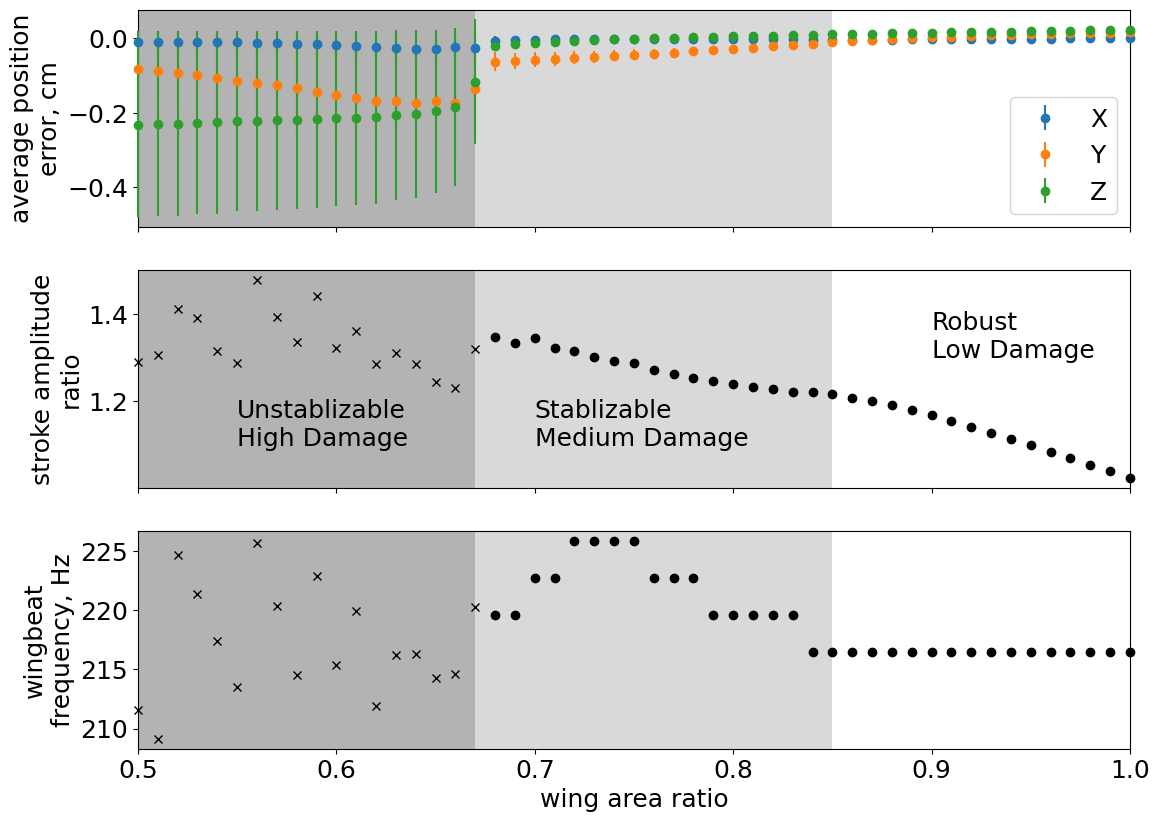

In [81]:
plot_kwargs = {"h":1440, "w":1920, "dpi":150}
# plotWingAngleVelocity(**plot_kwargs)
# plotAbdomenAngle(**plot_kwargs)
# plotBodyForces(4,**plot_kwargs)
# plotBodyForcesFFT(**plot_kwargs)
# plotWingAnglesFFT(**plot_kwargs)
# plotBodyPose(**plot_kwargs)
# plotAverageBodyForce(**plot_kwargs)
# plotWingAngles(4,**plot_kwargs)
# plotWingAnglesFFT(1,**plot_kwargs)
plotCompensation(**plot_kwargs)

In [ ]:
from scipy.io import loadmat
# mujires1 = loadmat("flybody-data/results/rsfs20160103supp2.mat")
mujires2 = loadmat("flybody-data/results/rsfs20160103supp3.mat")
# mujires3 = loadmat("flybody-data/results/rsfs20160103supp4.mat")
# print(mujires3["__header__"])
# print(mujires3.keys())

# Mujires's dataset contains force and torque readings that require post-processng to replicate publication figure 7ef
# The steps are, as confirmed via email correspondence,
# - rotate robot frame into fly frame (z=down to z=up)
# - offset torques to zero at damage condition

Fz_norm0 = mujires2["Fz_norm"][:,5].mean(axis=0)
Mx_norm0 = mujires2["Mx_norm"][:,5].mean(axis=0)
# Fz_norm_zeroed = 1-mujires2["Fz_norm"][:,5:35].mean(axis=0)+Fz_norm0 #+1-()+Fz_norm
# Mx_norm_zeroed = mujires2["Mx_norm"][:,5:35].mean(axis=0)-Mx_norm0
Fz_norm_zeroed = (-1*mujires2["Fz_norm"])[:,5:].mean(axis=0)
Mx_norm_zeroed = mujires2["Mx_norm"][:,5:].mean(axis=0)-mujires2["Mx_norm"][:,5].mean(axis=0)

# TODO: fix description of multi-variable curve fitting
def liftWRTDamageAndSAR(sar,s2):
    # undamaged freq
    a = -0.4412
    b = -0.01518
    c = 1.014
    d = -1.572
    # damaged freq
    # a = -0.6527
    # b = -0.02246
    # c = 1.501
    # d = -2.326
    return 1-(a+b*sar+c*s2+d*sar*s2)+Fz_norm0

def rollWRTDamageAndSAR(sar,s3):
    # undamaged freq
    a = .2836
    b = -.0327
    c = .5016
    d = -.8265
    # damaged freq
    # a = .4196
    # b = -.04837
    # c = .7421
    # d = -1.223
    return (a+b*sar+c*s3+d*sar*s3)-Mx_norm0

# print(mujires2.keys())
print("col\tS2_ratio\tS3_ratio\tSA_ratio\tcut_type\tMean_lift\tMean_roll")
cstack_i = slice(5,35)
print(np.column_stack((
    np.arange(cstack_i.start,cstack_i.stop),
    mujires2["S2_ratio"][cstack_i],
    mujires2["S3_ratio"][cstack_i],
    mujires2["Stroke_Amplitude_ratio"][cstack_i],
    mujires2["cut_type"][cstack_i],
    mujires2["Fz_norm"][:,cstack_i].mean(axis=0),
    mujires2["Mx_norm"][:,cstack_i].mean(axis=0))))

mujiresIndex = slice(10,35)
mujiresXY = np.array([
    [mujires2["S2_ratio"][i,0],mujires2["S3_ratio"][i,0],mujires2["Stroke_Amplitude_ratio"][i,0]]
    for i in range(mujiresIndex.start,mujiresIndex.stop)
])
mujiresZ = np.mean(mujires2["Fz_norm"][:,mujiresIndex],axis=0)
stroke_amp = np.zeros((2,results["warline"].size))
# TODO: Manually truncate values after failure
for m in np.arange(results["warline"].size):
    for side in [0,3]:
        angle = np.rad2deg(results["bodyPose"]["wing"][:,m,side])
        angle = angle[np.isfinite(angle)] # trim NaNs
        freq = rfftfreq(angle.size,_FLY_CONTROL_TIMESTEP)
        anglef = 2.0/angle.size * np.abs(rfft(angle)) #*blackman(angle.size)
        stroke_amp[int(side//3),m] = np.max(anglef[1:]) # stroke amplitude is going to be the max (truncate 0Hz)
stroke_amp_norm = (stroke_amp.T / stroke_amp[:,0]).T
sar = stroke_amp[1,:]/stroke_amp[0,:] # stroke amplitude ratio
moar2 = war2SecondMOAR(results["warline"])
moar3 = war2ThirdMOAR(results["warline"])
mx0 = mujires2["Mx_norm"][:,5].mean(axis=0)


fig, axes = plt.subplots(2,1,figsize=(10,15))
limits=((0.85,1.65),(0,1),(0.5,1.5))
axes[0].pcolormesh(
    np.linspace(*limits[0]),np.linspace(*limits[1]),
    np.array([
        [liftWRTDamageAndSAR(amp,s2) for amp in np.linspace(*limits[0])] 
        for s2 in np.linspace(*limits[1])]),
    cmap="PRGn_r",clim=limits[2],shading="gouraud")
axes[0].scatter(
    x=stroke_amp_norm[1,:m_fatal],
    y=moar2[:m_fatal], 
    c=np.nanmean(results["bodyForces"][:,:m_fatal,2],axis=0),
    marker="s",cmap="PRGn_r",clim=limits[2],edgecolors=(0,0,0,1), zorder=10, clip_on=False)
axes[0].scatter(
    x=mujires2["Stroke_Amplitude_ratio"][5:,0],
    y=mujires2["S2_ratio"][5:,0],
    c=Fz_norm_zeroed,
    marker="o",cmap="PRGn_r",clim=limits[2],edgecolors=(0,0,0,0.3),zorder=10, clip_on=False)
axes[0].set(
    ylabel="second moment of area ratio $S_2^*$",
    xlabel="stroke amplitude ratio $A^*$", 
)
fig.colorbar(
    mpl.cm.ScalarMappable(mpl.colors.Normalize(*limits[2]),cmap="PRGn_r"),
    ax=axes[0],
    label="normalized vertical force $\\left(F_z/mg\\right)$",
    ticks=(limits[2][0],(limits[2][1]-limits[2][0])/2,limits[2][1]))

limits=((0.85,1.65),(0,1),(-.3,.3))
axes[1].pcolormesh(
    np.linspace(*limits[0]),np.linspace(*limits[1]),
    np.array([
        [rollWRTDamageAndSAR(amp,s3) for amp in np.linspace(*limits[0])] 
        for s3 in np.linspace(*limits[1])]),
    cmap="PiYG_r",clim=limits[2],shading="gouraud")
axes[1].scatter(
    x=stroke_amp_norm[1,:m_fatal],
    y=moar2[:m_fatal], 
    c=np.nanmean(results["bodyForces"][:,:m_fatal,3],axis=0),
    marker="s",cmap="PiYG_r",clim=limits[2],edgecolors=(0,0,0,1), zorder=10, clip_on=False)
axes[1].scatter(
    x=mujires2["Stroke_Amplitude_ratio"][5:,0],
    y=mujires2["S3_ratio"][5:,0],
    c=Mx_norm_zeroed,
    marker="o",cmap="PiYG_r",clim=limits[2],edgecolors=(0,0,0,0.3),zorder=10, clip_on=False)
axes[1].set(
    ylabel="third moment of area ratio $S_3^*$",
    xlabel="stroke amplitude ratio $A^*$", 
)
fig.colorbar(
    mpl.cm.ScalarMappable(mpl.colors.Normalize(*limits[2]),cmap="PiYG_r"),
    ax=axes[1],
    label="normalized roll torque $\\left(T_x/mgl\\right)$",
    ticks=(limits[2][0],(limits[2][1]-limits[2][0])/2,limits[2][1]))

for ax in axes.flatten(): ax.minorticks_on()

# maybe save figure
fname = RESULTS_PATH/"mujires.pdf"
if ui["SAVE_RESULTS"] and not fname.exists(): fig.savefig(fname.as_posix())

col	S2_ratio	S3_ratio	SA_ratio	cut_type	Mean_lift	Mean_roll
[[ 5.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   0.00000000e+00 -1.07354901e+00 -6.54338349e-02]
 [ 6.00000000e+00  1.00000000e+00  1.00000000e+00  1.06039920e+00
   0.00000000e+00 -1.14401319e+00 -1.15935570e-01]
 [ 7.00000000e+00  1.00000000e+00  1.00000000e+00  1.12079839e+00
   0.00000000e+00 -1.23390582e+00 -1.71774271e-01]
 [ 8.00000000e+00  1.00000000e+00  1.00000000e+00  1.18119759e+00
   0.00000000e+00 -1.32115910e+00 -2.25018959e-01]
 [ 9.00000000e+00  1.00000000e+00  1.00000000e+00  1.24159678e+00
   0.00000000e+00 -1.43180819e+00 -2.86711233e-01]
 [ 1.00000000e+01  1.49783871e-01  8.35153130e-02  1.00000000e+00
   1.00000000e+00 -5.57891239e-01  2.06187310e-01]
 [ 1.10000000e+01  1.49783871e-01  8.35153130e-02  1.06039920e+00
   1.00000000e+00 -5.96667436e-01  2.22176908e-01]
 [ 1.20000000e+01  1.49783871e-01  8.35153130e-02  1.12079839e+00
   1.00000000e+00 -6.13229103e-01  2.08239705e-01]
 [ 1

NameError: name 'rfftfreq' is not defined